# Poker Dataset Exploration
Absolute Poker NLH 2009 â€” population study

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from parser import load_file, load_directory
from hand_utils import hand_summary, assign_positions, final_pot, count_preflop_raises

## Load hands

In [2]:
DATA_FILE = '../abs NLH handhq_1-OBFUSCATED.phhs'

hands = load_file(DATA_FILE)
print(f'Loaded {len(hands):,} hands')

Loaded 1,000 hands


## Build summary DataFrame

In [3]:
rows = [hand_summary(h) for h in hands]
df = pd.DataFrame(rows)
df.head()

,hand_id,file,date,table,n_players,pot_final,n_preflop_raises,went_to_showdown,is_multiway,n_actions,has_winnings
0,3017235114,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,DEFIANCE ST,5,1.50,0,False,False,9,True
1,3017237934,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,1.50,0,False,False,3,True
2,3017234966,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,MORGAN CT,6,3.25,1,False,False,12,True
3,3017238288,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,1.75,0,False,False,6,True
4,3017238782,abs NLH handhq_1-OBFUSCATED.phhs,2009-07-01,GERMANY HWY,2,2.50,1,False,False,4,True


In [4]:
df.describe()

,hand_id,n_players,pot_final,n_preflop_raises,n_actions
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.017338e+09,5.610000,11.708930,0.614000,18.157000
std,5.335087e+04,2.141141,18.094909,0.653782,7.998896
min,3.017235e+09,2.000000,1.000000,0.000000,3.000000
25%,3.017293e+09,5.000000,2.750000,0.000000,12.000000
50%,3.017341e+09,6.000000,4.750000,1.000000,18.000000
75%,3.017384e+09,7.000000,11.250000,1.000000,24.000000
max,3.017436e+09,9.000000,188.510000,5.000000,44.000000


## Player count distribution

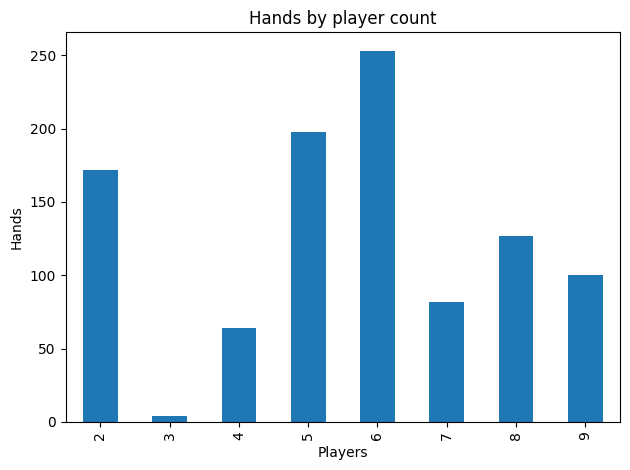

In [5]:
df['n_players'].value_counts().sort_index().plot(kind='bar', title='Hands by player count')
plt.xlabel('Players')
plt.ylabel('Hands')
plt.tight_layout()
plt.show()

## Pot size distribution

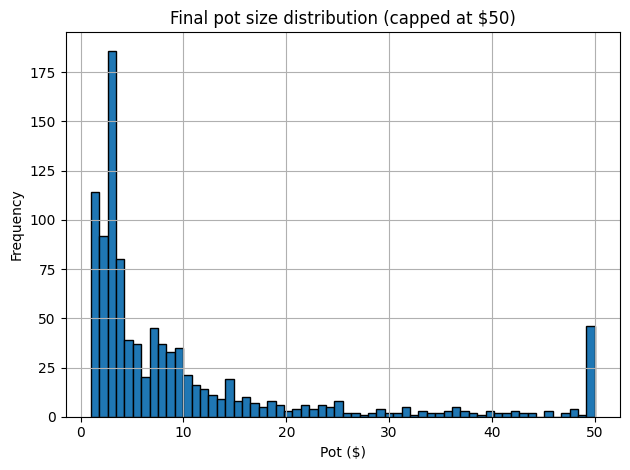

In [7]:
df['pot_final'].clip(upper=50).hist(bins=60, edgecolor='black')
plt.title('Final pot size distribution (capped at $50)')
plt.xlabel('Pot ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Preflop aggression

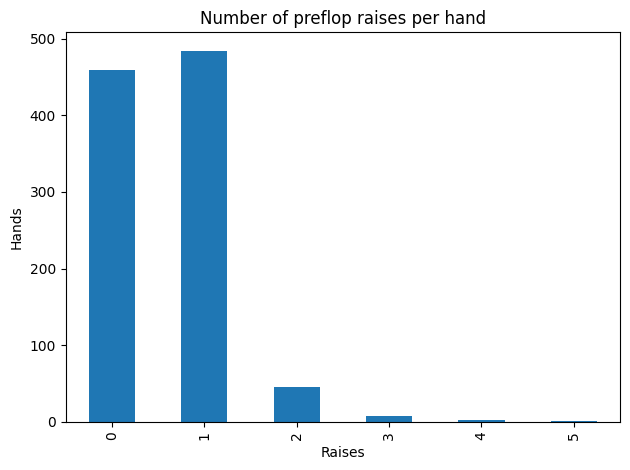

3bet+ rate: 5.7%
4bet+ rate: 1.1%


In [9]:
df['n_preflop_raises'].value_counts().sort_index().plot(
    kind='bar', title='Number of preflop raises per hand')
plt.xlabel('Raises')
plt.ylabel('Hands')
plt.tight_layout()
plt.show()

print('3bet+ rate: {:.1%}'.format((df['n_preflop_raises'] >= 2).mean()))
print('4bet+ rate: {:.1%}'.format((df['n_preflop_raises'] >= 3).mean()))

## Showdown rate

In [10]:
sd_rate = df['went_to_showdown'].mean()
print(f'Showdown rate: {sd_rate:.1%}')

Showdown rate: 29.2%


## Tables

In [11]:
df['table'].value_counts().head(20)

table
CAMERON ST     149
DEFIANCE ST    104
DOHENY AVE      97
ENGLAND AVE     92
JARVIS AVE      72
DAISY DR        70
MARINER DR      68
ALATNA AVE      64
CHAPEL HILL     63
BAGPIPE AVE     61
BRADFORD DR     54
MORGAN CT       42
CANADA HWY      41
GERMANY HWY     23
Name: count, dtype: int64

## Sample hand inspection

In [12]:
h = hands[5]   # change index to explore different hands
print(f'Hand {h.hand_id}  table={h.table}  date={h.date_str}')
print(f'Players ({h.n_players}): {h.players}')
print(f'Stacks: {h.starting_stacks}')
print(f'Blinds: {h.blinds_or_straddles}')
print(f'Winnings: {h.winnings}')
print()
print('Actions:')
for i, a in enumerate(h.actions):
    print(f'  [{i:2d}] {a}')

Hand 3017236188  table=DOHENY AVE  date=2009-07-01
Players (6): ['+a5SqgTrPaSUEIxiX2tP4w', 'NGMyPrCItsd+XnR3unPJWA', 'Pcbrz/bBnpt30AolVBpqjQ', '5IsB9AM26bmoKc4kPVeUwQ', 'jkG6SgyvJ7/U3HnU0LBs/w', 'lOKkle8LDdJoCkV0V7aIAQ']
Stacks: [49.5, 70.69, 12.0, 18.5, 26.15, 117.05]
Blinds: [0.25, 0.5, 0.0, 0.0, 0.0, 0.0]
Winnings: [0.0, 0.0, 0.0, 4.55, 0.0, 0.0]

Actions:
  [ 0] d dh p1 ????
  [ 1] d dh p2 ????
  [ 2] d dh p3 ????
  [ 3] d dh p4 ????
  [ 4] d dh p5 ????
  [ 5] d dh p6 ????
  [ 6] p3 cc
  [ 7] p4 cc
  [ 8] p5 f
  [ 9] p6 f
  [10] p1 f
  [11] p2 cbr 1.50
  [12] p3 cc
  [13] p4 cc
  [14] d db 5h2s8h
  [15] p2 cc
  [16] p3 cc
  [17] p4 cbr 1.50
  [18] p2 f
  [19] p3 f


## Run auto-labeller and check results

In [13]:
from labeller import label_hand, get_connection, insert_labels

conn = get_connection()
total_inserted = 0
for h in hands:
    rows_lbl = label_hand(h)
    total_inserted += insert_labels(rows_lbl, conn)
conn.close()
print(f'Inserted {total_inserted:,} label rows')

Inserted 0 label rows


In [14]:
from analyser import Analyser

an = Analyser()
print(an.summary())
print()

counts_df = an.label_counts_df()
counts_df

{'total_labelled_hands': 910, 'total_label_rows': 2207, 'unique_labels': 11}



,label,count
0,rfi,484
1,single_raised_pot,484
2,limp_pot,369
3,showdown,292
4,multi_way,280
5,cbet_flop,192
6,3bet_pot,46
7,check_raise_flop,23
8,all_in_preflop,18
9,4bet_pot,11


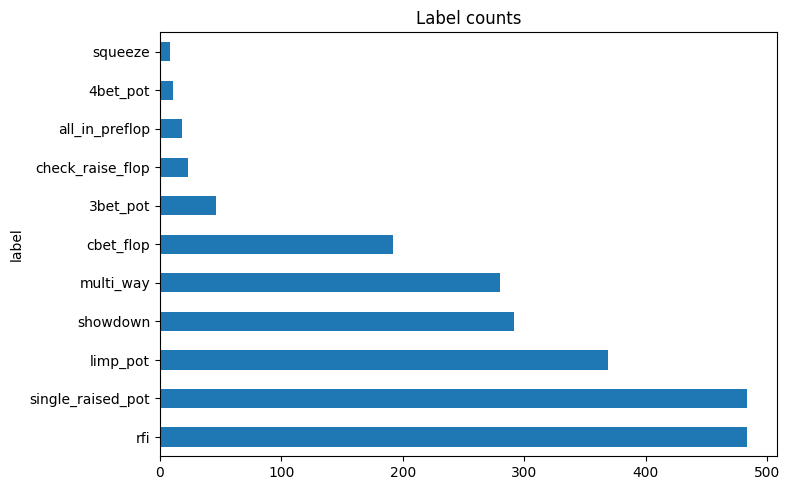

In [15]:
counts_df.set_index('label')['count'].plot(
    kind='barh', title='Label counts', figsize=(8, 5))
plt.tight_layout()
plt.show()

---
## Player earnings & filtering (`db/poker.db`)

Queries against the `player_hands` table populated by `src/ingest.py`.

In [ ]:
import sqlite3

con = sqlite3.connect('../db/poker.db')
n_rows = con.execute('SELECT COUNT(*) FROM player_hands').fetchone()[0]
n_hands = con.execute('SELECT COUNT(DISTINCT hand_id) FROM player_hands').fetchone()[0]
print(f'{n_rows:,} player-hand rows across {n_hands:,} hands')

### Earnings leaderboard

In [ ]:
earnings = pd.read_sql("""
    SELECT player_id, COUNT(*) hands,
           ROUND(SUM(winnings), 2)          earnings,
           ROUND(AVG(winnings), 4)           avg_per_hand
    FROM player_hands WHERE winnings IS NOT NULL
    GROUP BY player_id ORDER BY earnings DESC
""", con)

print('Top 10 winners')
display(earnings.head(10))
print('\nTop 10 losers')
display(earnings.tail(10))

In [ ]:
top20 = earnings.head(20).copy()
top20['label'] = top20['player_id'].str[:8]
top20.set_index('label')['earnings'].plot(
    kind='bar', figsize=(12, 4), color='steelblue',
    title='Top 20 earners (truncated player ID)')
plt.ylabel('Earnings ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Positional profitability

In [ ]:
pos_stats = pd.read_sql("""
    SELECT position,
           COUNT(*)                                              hands,
           ROUND(SUM(winnings), 2)                              total_earnings,
           ROUND(SUM(winnings) /
                 SUM(CASE WHEN winnings IS NOT NULL THEN 1 END), 4) avg_per_hand,
           ROUND(100.0 * SUM(saw_flop)   / COUNT(*), 1)        flop_seen_pct,
           ROUND(100.0 * SUM(went_to_sd) / COUNT(*), 1)        showdown_pct
    FROM player_hands
    GROUP BY position ORDER BY total_earnings DESC
""", con)
pos_stats

In [ ]:
pos_order = [p for p in ['BTN','CO','HJ','UTG','SB','BB','SB/BTN']
             if p in pos_stats['position'].values]
ps = pos_stats.set_index('position').reindex(pos_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ps['total_earnings'].plot(kind='bar', ax=axes[0], color='steelblue',
                          title='Total earnings by position')
axes[0].set_ylabel('Earnings ($)')
axes[0].tick_params(axis='x', rotation=0)

ps['flop_seen_pct'].plot(kind='bar', ax=axes[1], color='darkorange',
                         title='Flop seen % by position')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Earnings by pot type

Join `player_hands` with `labels` to slice stats by preflop situation.

In [ ]:
pot_types = ['limp_pot', 'single_raised_pot', '3bet_pot', '4bet_pot', 'squeeze']
rows = []
for label in pot_types:
    r = pd.read_sql("""
        SELECT COUNT(DISTINCT ph.hand_id)              unique_hands,
               ROUND(SUM(ph.winnings), 2)              total_action,
               ROUND(100.0 * SUM(ph.went_to_sd)
                     / COUNT(*), 1)                    sd_pct,
               ROUND(100.0 * SUM(ph.saw_flop)
                     / COUNT(*), 1)                    flop_seen_pct
        FROM player_hands ph
        JOIN labels l ON ph.hand_id = l.hand_id
        WHERE l.label = ?
    """, con, params=[label]).iloc[0].to_dict()
    r['pot_type'] = label
    rows.append(r)

pd.DataFrame(rows).set_index('pot_type')

### Player deep-dive

Break down the top earner's results by position and situation type.

In [ ]:
top_pid   = earnings.iloc[0]['player_id']
top_earn  = earnings.iloc[0]['earnings']
top_hands = earnings.iloc[0]['hands']
print(f'Player:   {top_pid}')
print(f'Earnings: ${top_earn:.2f} over {top_hands} hands  (${top_earn/top_hands:.3f}/hand avg)')

print('\nBy position:')
display(pd.read_sql("""
    SELECT position, COUNT(*) hands,
           ROUND(SUM(winnings), 2)                    earnings,
           ROUND(100.0 * SUM(saw_flop) / COUNT(*), 1) flop_seen_pct
    FROM player_hands
    WHERE player_id = ? AND winnings IS NOT NULL
    GROUP BY position ORDER BY earnings DESC
""", con, params=[top_pid]))

print('\nBy situation label:')
display(pd.read_sql("""
    SELECT l.label, COUNT(*) hands,
           ROUND(SUM(ph.winnings), 2) earnings
    FROM player_hands ph
    JOIN labels l ON ph.hand_id = l.hand_id
    WHERE ph.player_id = ? AND ph.winnings IS NOT NULL
    GROUP BY l.label ORDER BY earnings DESC
""", con, params=[top_pid]))